<p style="text-align:right;">Mario Stanke, Felix Becker, University of Greifswald, Germany</p>

## CNN to distinguish cats, dogs, wolves and plants
In this notebook we will perform image classification with a convolutional neural network. We will use a dataset of photos of 3 animals (tabby cats, German shepherds and grey woves) and plants seedlings of 9 plant species. The animal photos were downloaded from [IMAGENET](http://www.image-net.org/). The plant dataset is an excerpt from https://www.kaggle.com/vbookshelf/a-simple-keras-solution. All input images are in subfolders of ```data/cats-dogs-plants``` respective to their class.

What you will learn: 
 - convolutional layers (Conv2D)
 - handling of image datasets (TorchVision)
 - image augmentation
 - monitoring training progress (callbacks)
 - saving and reading a model to and from a file
 - classification error analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import math
import cv2
import random
from itertools import cycle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchsummary import summary
from torch.optim.lr_scheduler import ReduceLROnPlateau
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
                         

In [2]:
print (torch.__version__)


1.12.1


## Image Data Preparation - Make Data Frames
We will create **Pandas data frames** to hold the *file names and class labels only*. These data structures are small as they do not contain the actual image data. The images are on the drive and never are they all loaded to memory, so this approach scales to very large training sets of images.

In [3]:
# directory with image class subdirectories
img_path = '../data/cats-dogs-plants'

# Create a pandas dataframe from a tab separated file 
df = pd.read_csv(img_path + "/classes-and-fnames.txt", sep = '\t', names = ['classname', 'fname'])
df['path'] = img_path + '/' + df['classname'] + "/" + df['fname']

df.head()

,classname,fname,path
0,cat,1000.png,../data/cats-dogs-plants/cat/1000.png
1,cat,1001.png,../data/cats-dogs-plants/cat/1001.png
2,cat,1002.png,../data/cats-dogs-plants/cat/1002.png
3,cat,1003.png,../data/cats-dogs-plants/cat/1003.png
4,cat,1005.png,../data/cats-dogs-plants/cat/1005.png


In [4]:
#check how many images we have in total
df.shape

(7440, 3)

In [5]:
# associate class names with a class (0 .. K-1)
classnames = df['classname'].unique() # all 12 species names

K = classnames.size  # 12
name2class = dict(zip(classnames, range(K))) # dictionary that maps a name to its index in classnames array
name2class

{'cat': 0,
 'shepherd': 1,
 'wolf': 2,
 'CommonWheat': 3,
 'Maize': 4,
 'Small-floweredCranesbill': 5,
 'Charlock': 6,
 'FatHen': 7,
 'ScentlessMayweed': 8,
 'SugarBeet': 9,
 'CommonChickweed': 10,
 'LooseSilky-bent': 11}

In [6]:
# Add a column 'class' to data frame  with the number representing the species name
df['class'] = df['classname'].map(name2class) # new column class with number representing plant name

# print a few random example lines
df.sample(n=5)

,classname,fname,path,class
7241,LooseSilky-bent,625.png,../data/cats-dogs-plants/LooseSilky-bent/625.png,11
3737,Small-floweredCranesbill,471.png,../data/cats-dogs-plants/Small-floweredCranesb...,5
1910,shepherd,89.png,../data/cats-dogs-plants/shepherd/89.png,1
6597,CommonChickweed,672.png,../data/cats-dogs-plants/CommonChickweed/672.png,10
670,cat,690.png,../data/cats-dogs-plants/cat/690.png,0


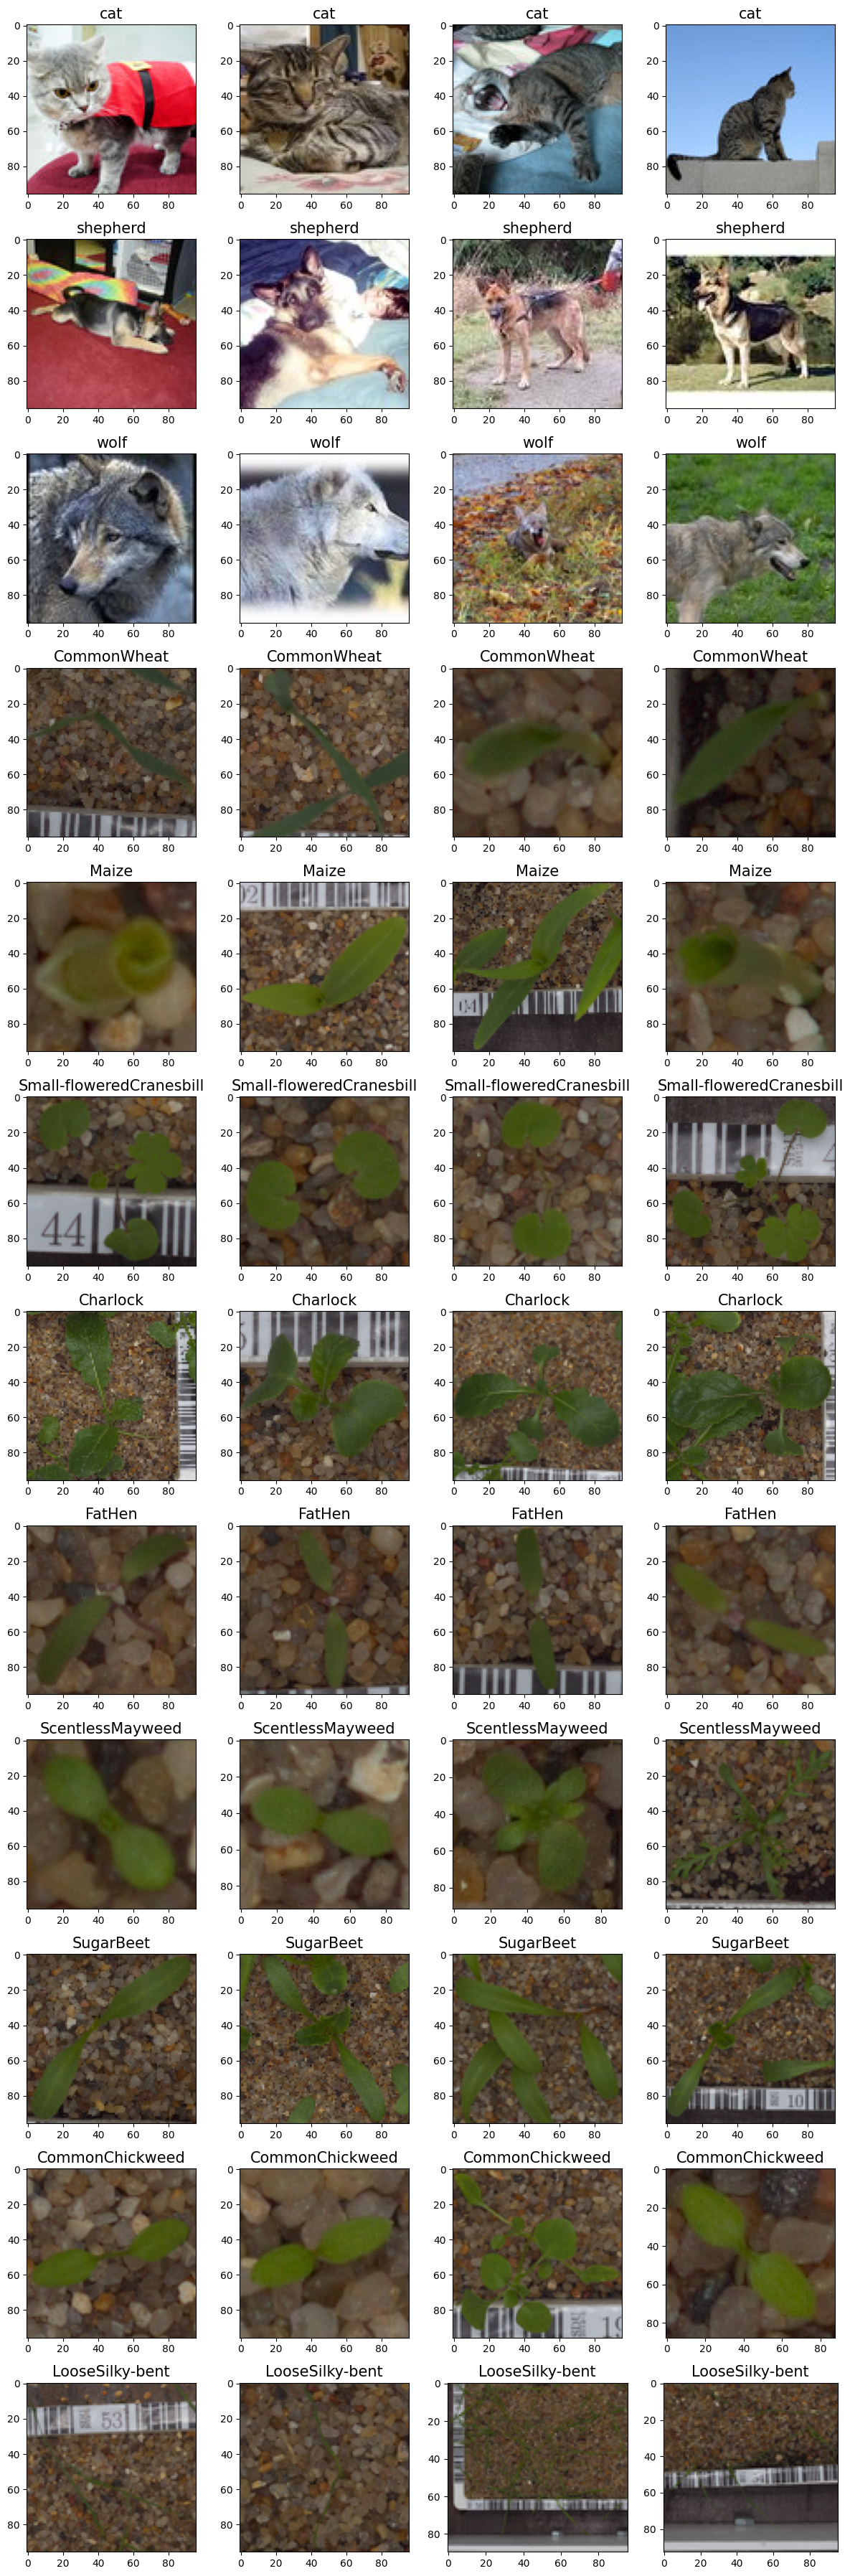

In [7]:
# Plot a few sample images for each class
examples_per_class = 4
_, ax = plt.subplots(nrows = K, ncols = examples_per_class, 
                     figsize = (3 * examples_per_class, 3 * K)) # adjust size here
    
for i in range(K): # loop over classes = rows
    sample = df[df['class'] == i].sample(n = examples_per_class)
    for j in range(examples_per_class):
        path = sample.iloc[j]['path']
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # cv2 has color order BGR rather than RGB
        ax[i, j].imshow(img)
        ax[i, j].set_title(classnames[i], fontsize=15)  
plt.tight_layout()
plt.show()

In [8]:
num_animals = 3 # assume that the first classes are animals
# percentages for the relative frequencies of each plant
100 * df['classname'].value_counts() / df.shape[0]

cat                         13.588710
shepherd                    13.575269
wolf                        10.725806
LooseSilky-bent             10.241935
CommonChickweed              9.583333
ScentlessMayweed             8.158602
Small-floweredCranesbill     7.741935
FatHen                       7.231183
SugarBeet                    6.223118
Charlock                     6.075269
Maize                        3.454301
CommonWheat                  3.400538
Name: classname, dtype: float64

**Question:** What is the fraction of correct guesses (accuracy) you are expected to get with a good random guessing method, i.e. without even looking at a photo?

### Training, Validation and Test Split

In [9]:
# randomly split data frame into training, validation and test data frames
num_imgs  = df.shape[0] # total number of examples
num_test  = 400 # size of test set, used only once at end
num_val   = 300 # size of validation set, used to monitor training progress
num_train = num_imgs - num_test - num_val # size of training set, the (large) rest

assert num_train > 0, "Error: examples consumed by test and validation sets alone"

# construct an array [0, 1, ..., num_imgs] with the indices = row numbers of df
all_idxs = np.array(range(num_imgs))
np.random.shuffle(all_idxs) # random order, so there is no bias in any partition

# construct training and testing data frames 
test_df = df.iloc[all_idxs[0 : num_test]]
val_df = df.iloc[all_idxs[num_test : num_test + num_val]]
train_df = df.iloc[all_idxs[num_test + num_val :]] # the rest

assert train_df.shape[0] == num_train, "Internal error of 3-way split into train, test, val"
print("Sizes: train =", num_train, "\tvalidation =", num_val, "\ttest =", num_test)

Sizes: train = 6740 	validation = 300 	test = 400


## Prepare an Image Data, Image Augmentation

From one image on the drive one can generate many training examples, e.g.

 - by mirroring and rotating the image where it preserves the label
 - by random cropping followed by resizing
 - by random changes to colors.
    
**Goals:**
 - Have a much larger effective training set (the bigger the better).
 - Make it more robust with respect to biases, e.g. the direction of light during photography may have
    had a systematic bias, say, if maize was on one side of the greenhouse and sugar beets on the other. 

In [10]:
img_size = 96    # width and height of images when input to the model (an image will be resized, if required)
batch_size = 32  # for training and prediction

In [11]:
# Define transforms. We use a basic transform and include random horizontal flips,
# color jitter, and (conditionally) 90° rotations.
class CustomAugment:
    def __init__(self, img_size):
        self.resize = transforms.Resize((img_size, img_size))
        self.to_tensor = transforms.ToTensor()
        self.color_jitter = transforms.ColorJitter(brightness=0.1, saturation=0.05, hue=0.05)
        self.hflip = transforms.RandomHorizontalFlip(p=0.5)
        
    def __call__(self, img, label):
        # img is a numpy array in RGB
        img = self.resize(transforms.ToPILImage()(img))
        
        # 50% chance to mirror vertically
        img = self.hflip(img)
        
        # For plant images (label >= num_animals), also randomly rotate in 90° increments.
        if label >= num_animals:
            # rotation by 0, 90, 180 or 270 degrees.
            rot_deg = random.choice([0, 90, 180, 270])
            img = transforms.functional.rotate(img, rot_deg)
        img = self.color_jitter(img)
        # Finally convert to tensor
        img = self.to_tensor(img)
        return img

class ImageDataset(Dataset):
    def __init__(self, df, augment=True):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.augmenter = CustomAugment(img_size) if augment else None
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['path']
        # load image with cv2; note cv2 loads in BGR format
        img = cv2.imread(path)
        # If image is not loaded, raise an error
        if img is None:
            raise ValueError(f"Image {path} could not be loaded")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Use augmentations if desired
        if self.augmenter is not None:
            img = self.augmenter(img, int(row['class']))
        else:
            # Otherwise, simply resize and convert to tensor.
            img = cv2.resize(img, (img_size, img_size))
            img = transforms.ToTensor()(img)
        label = int(row['class'])
        return img, label

# Create datasets for train, validation, and test.
train_ds = ImageDataset(train_df, augment=True)
val_ds   = ImageDataset(val_df, augment=False)
test_ds  = ImageDataset(test_df, augment=False)

# Create DataLoaders.
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
train_loader_unshuff = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=4) # for testing
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)

In [12]:
# generate one training example from the loader
data_iter = iter(train_loader)
sample_img, sample_label = next(data_iter)
print("Batch image tensor shape:", sample_img.shape)
print("First label in batch:", sample_label[0])

Batch image tensor shape: torch.Size([32, 3, 96, 96])
First label in batch: tensor(2)


A DataLoader is iterable. We can use a simple for-loop to iterate over elements:

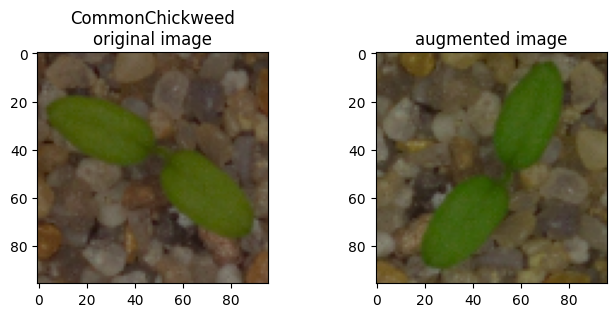

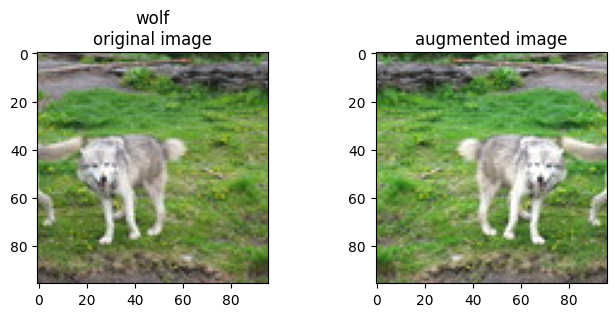

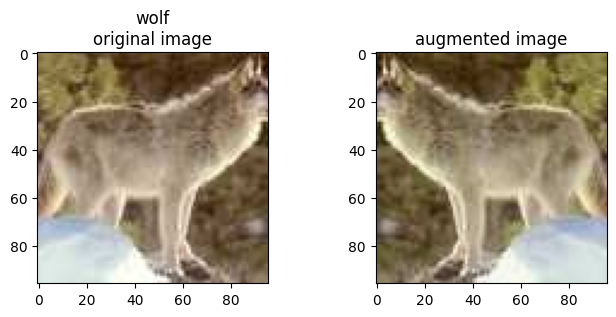

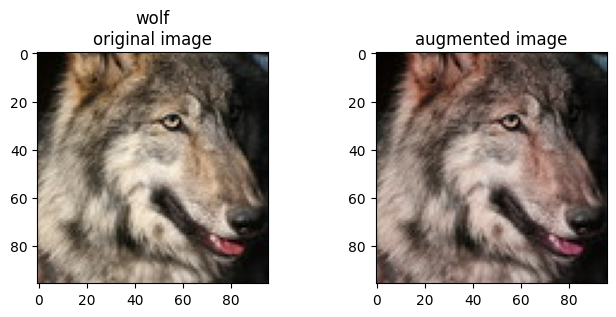

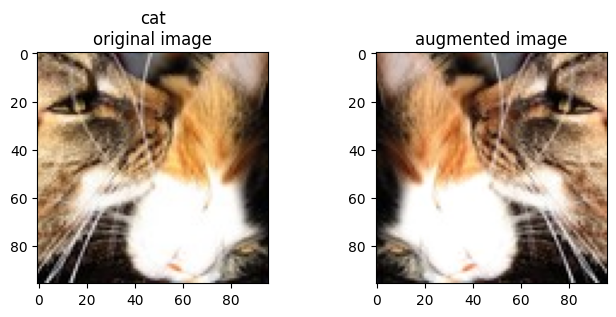

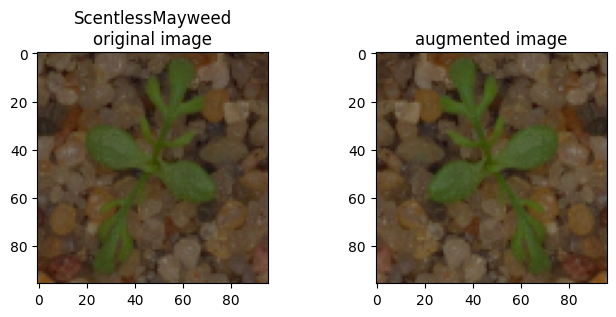

In [13]:
# print and display first example from first batch

x, y = next(iter(train_loader_unshuff))
for i in range(6):
    _, ax = plt.subplots(ncols = 2, figsize = (8, 3))

    # plot original image as on drive
    path = train_df.iloc[i]['path']
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    ax[0].imshow(img)
    ax[0].set_title(classnames[y[i].numpy()] + "\noriginal image")

    # plot augmented image
    ax[1].imshow(x[i].permute(1, 2, 0))
    ax[1].set_title("augmented image");

## Define and Train a Convolutional Neural Network
**Layer types:**
 - Conv2D convolutional layer, here inputs are 3dim and the convolution sums over the 3rd dim.
 - [MaxPooling2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) takes local maxima over a rectangular region.
 - [Dropout](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) randomly deactivates neurons during training, which can make training more robust.
 - [BatchNormalization](https://arxiv.org/pdf/1502.03167.pdf), centralizes and scales its input to have approximately 0 mean and variance 1.

Model architecture modified from [this source](https://www.kaggle.com/fmarazzi/baseline-keras-cnn-roc-fast-5min-0-8253-lb)

In [14]:
# Set random seed for reproducibility
torch.manual_seed(1)

# Hyperparameters (similar to TF values)
kernel_size = 3        # equivalent to (3,3)
pool_size = 2          # max pooling size 2x2
first_filters = 32
second_filters = 64
third_filters = 128
dropout_conv = 0.3
dropout_dense = 0.3

class CNNClassifier(nn.Module):
    def __init__(self, num_classes, img_size):
        super(CNNClassifier, self).__init__()
        # input normalization can be done via a BatchNorm2d over 3 channels
        self.input_bn = nn.BatchNorm2d(3)
        # First block
        self.block1 = nn.Sequential(
            nn.Conv2d(3, first_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(first_filters, first_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(first_filters, first_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout_conv)
        )
        # Second block
        self.block2 = nn.Sequential(
            nn.Conv2d(first_filters, second_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(second_filters, second_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(second_filters, second_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout_conv)
        )
        # Third block
        self.block3 = nn.Sequential(
            nn.Conv2d(second_filters, third_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(third_filters, third_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.Conv2d(third_filters, third_filters, kernel_size, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout_conv)
        )
        # Compute flattened feature size after 3 poolings
        flattened_size = 4608 # depends on the architecture,
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_dense),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.input_bn(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Create model instance
model = CNNClassifier(num_classes=K, img_size=img_size).to(device)
summary(model, (3, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
       BatchNorm2d-1            [-1, 3, 96, 96]               6
            Conv2d-2           [-1, 32, 94, 94]             896
              ReLU-3           [-1, 32, 94, 94]               0
            Conv2d-4           [-1, 32, 92, 92]           9,248
              ReLU-5           [-1, 32, 92, 92]               0
            Conv2d-6           [-1, 32, 90, 90]           9,248
              ReLU-7           [-1, 32, 90, 90]               0
         MaxPool2d-8           [-1, 32, 45, 45]               0
           Dropout-9           [-1, 32, 45, 45]               0
           Conv2d-10           [-1, 64, 43, 43]          18,496
             ReLU-11           [-1, 64, 43, 43]               0
           Conv2d-12           [-1, 64, 41, 41]          36,928
             ReLU-13           [-1, 64, 41, 41]               0
           Conv2d-14           [-1, 64,

In [15]:
# Use CrossEntropyLoss, which expects raw logits (no softmax) and integer labels.
criterion = nn.CrossEntropyLoss()

def combined_loss_fn(outputs, targets, model):
    # Compute the base loss (data loss)
    data_loss = criterion(outputs, targets)
    
    # Compute regularization loss on the model
    lambda_val = 0.005
    l2_loss = 0.0
    for param in model.classifier.parameters(): # most parameters here
        l2_loss += torch.sum(param ** 2)
    
    # Return the sum of data loss and L2 loss scaled by lambda
    return data_loss + lambda_val * l2_loss

# Use Adam optimizer with a learning rate similar to TF.
current_lr = 0.001
optimizer = optim.Adam(model.parameters(), lr=current_lr)

# Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=4)

In [16]:
# Training loop with history accumulation
num_epochs = 50 # 50, set to your desired number of epochs
steps_per_epoch = 600 # 600, number of batches

history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}
best_val_loss = float("inf")
model_save_path = "animals_and_plants.pth"

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_total = 0
    train_correct = 0
    for i, (imgs, labels) in enumerate(cycle(train_loader)):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = combined_loss_fn(outputs, labels, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        train_total += imgs.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        if i>= steps_per_epoch:
            break
    
    avg_train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_total = 0
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = combined_loss_fn(outputs, labels, model)
            val_loss += loss.item() * imgs.size(0)
            val_total += imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
    
    avg_val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    # Save the epoch metrics in history dictionary
    history['loss'].append(avg_train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} -- Train loss: {avg_train_loss:.4f}, Train acc: {train_acc:.4f} ; Val loss: {avg_val_loss:.4f}, Val acc: {val_acc:.4f}")
    
    # Save the best model according to validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_save_path)
        print("Saved best model.")

    # Update learning rate based on validation loss, too
    scheduler.step(avg_val_loss)
    new_lr = scheduler.optimizer.param_groups[0]['lr']
    if current_lr != new_lr:
        current_lr = new_lr
        print(f"Learning rate updated to: {current_lr}")


Epoch 1/50 -- Train loss: 1.7066, Train acc: 0.3385 ; Val loss: 1.3723, Val acc: 0.4933
Saved best model.
Epoch 2/50 -- Train loss: 1.4144, Train acc: 0.4536 ; Val loss: 1.2930, Val acc: 0.5300
Saved best model.
Epoch 3/50 -- Train loss: 1.3205, Train acc: 0.5123 ; Val loss: 1.1594, Val acc: 0.5500
Saved best model.
Epoch 4/50 -- Train loss: 1.2279, Train acc: 0.5719 ; Val loss: 1.0830, Val acc: 0.5833
Saved best model.
Epoch 5/50 -- Train loss: 1.1318, Train acc: 0.6172 ; Val loss: 0.9786, Val acc: 0.6667
Saved best model.
Epoch 6/50 -- Train loss: 1.0631, Train acc: 0.6384 ; Val loss: 0.9308, Val acc: 0.7133
Saved best model.
Epoch 7/50 -- Train loss: 0.9742, Train acc: 0.6931 ; Val loss: 0.7753, Val acc: 0.7700
Saved best model.
Epoch 8/50 -- Train loss: 0.9046, Train acc: 0.7243 ; Val loss: 0.7624, Val acc: 0.8067
Saved best model.
Epoch 9/50 -- Train loss: 0.8407, Train acc: 0.7502 ; Val loss: 0.7121, Val acc: 0.8033
Saved best model.
Epoch 10/50 -- Train loss: 0.8051, Train acc: 

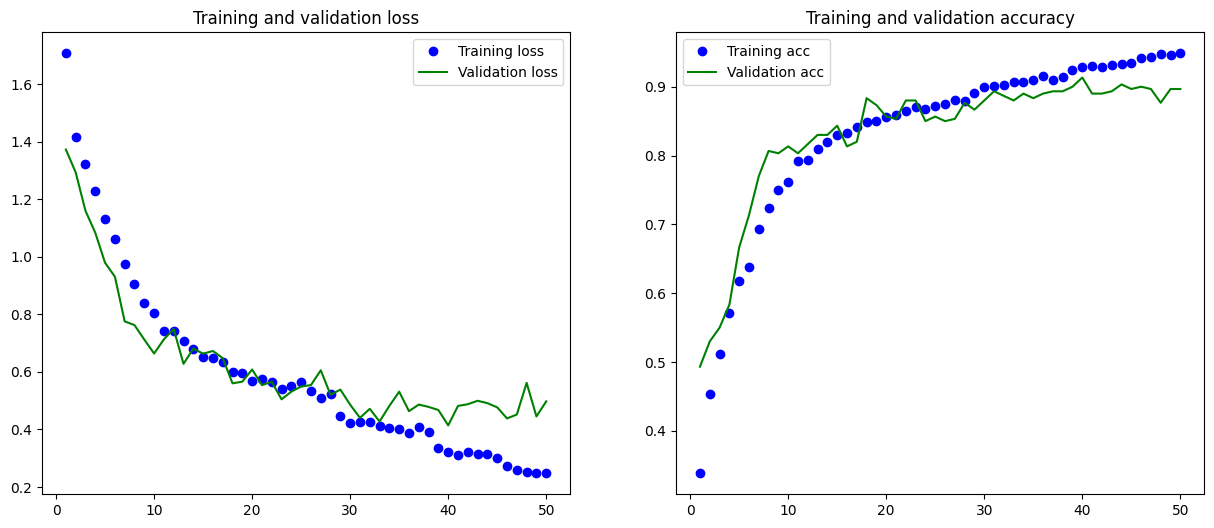

In [17]:
# plot the training history as loss and accuracy curves
epochs = range(1, len(history['accuracy']) + 1)

_, ax = plt.subplots(ncols = 2, figsize = (15, 6))
ax[0].plot(epochs, history['loss'], 'bo', label = 'Training loss')
ax[0].plot(epochs, history['val_loss'], 'g', label = 'Validation loss')
ax[0].set_title('Training and validation loss')
ax[0].legend()

ax[1].plot(epochs, history['accuracy'], 'bo', label = 'Training acc')
ax[1].plot(epochs, history['val_accuracy'], 'g', label = 'Validation acc')
ax[1].set_title('Training and validation accuracy')
ax[1].legend();

If we see that the validation results stagnate or worsen while the training results improve, this would suggest overfitting. We can then
1. reduce the complexity of our model (drop some layers or decrease the number of filters),

2. regularize more (increase dropout, L2 regularization or do more image augmentation) or

3. collect more data.

## Evaluation after Training

In [18]:
# Load the best model stored from training
model.load_state_dict(torch.load(model_save_path))
model.eval()

test_loss = 0.0
test_total = 0
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * imgs.size(0)
        test_total += imgs.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / test_total
test_acc = test_correct / test_total

print("Loss on test set:", avg_test_loss)
print("Accuracy on test set:", test_acc)

Loss on test set: 0.22193684682250023
Accuracy on test set: 0.9325


In [19]:
# For predictions we already computed predictions on the test set.
# Create a confusion matrix and classification report:
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classnames, zero_division=0))

Confusion Matrix:
[[57  5  5  0  0  0  0  1  0  0  0  0]
 [ 1 55  4  0  0  0  0  0  0  0  0  0]
 [ 3  1 28  1  0  0  0  0  0  0  0  0]
 [ 0  0  0 14  0  0  0  0  0  0  0  1]
 [ 0  0  0  0 10  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 31  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 19  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 35  0  0  0  0]
 [ 0  0  0  1  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  1  0  1  0  1 19  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0  0  0  1  0 35]]

Classification Report:
                          precision    recall  f1-score   support

                     cat       0.93      0.84      0.88        68
                shepherd       0.90      0.92      0.91        60
                    wolf       0.76      0.85      0.80        33
             CommonWheat       0.88      0.93      0.90        15
                   Maize       0.91      1.00      0.95        10
Small-floweredCranesbill       1.00      1.00      1.00        31
                Charlock  

### Display misclassified photos of animals

Number of misclassifications involving an animal: 21


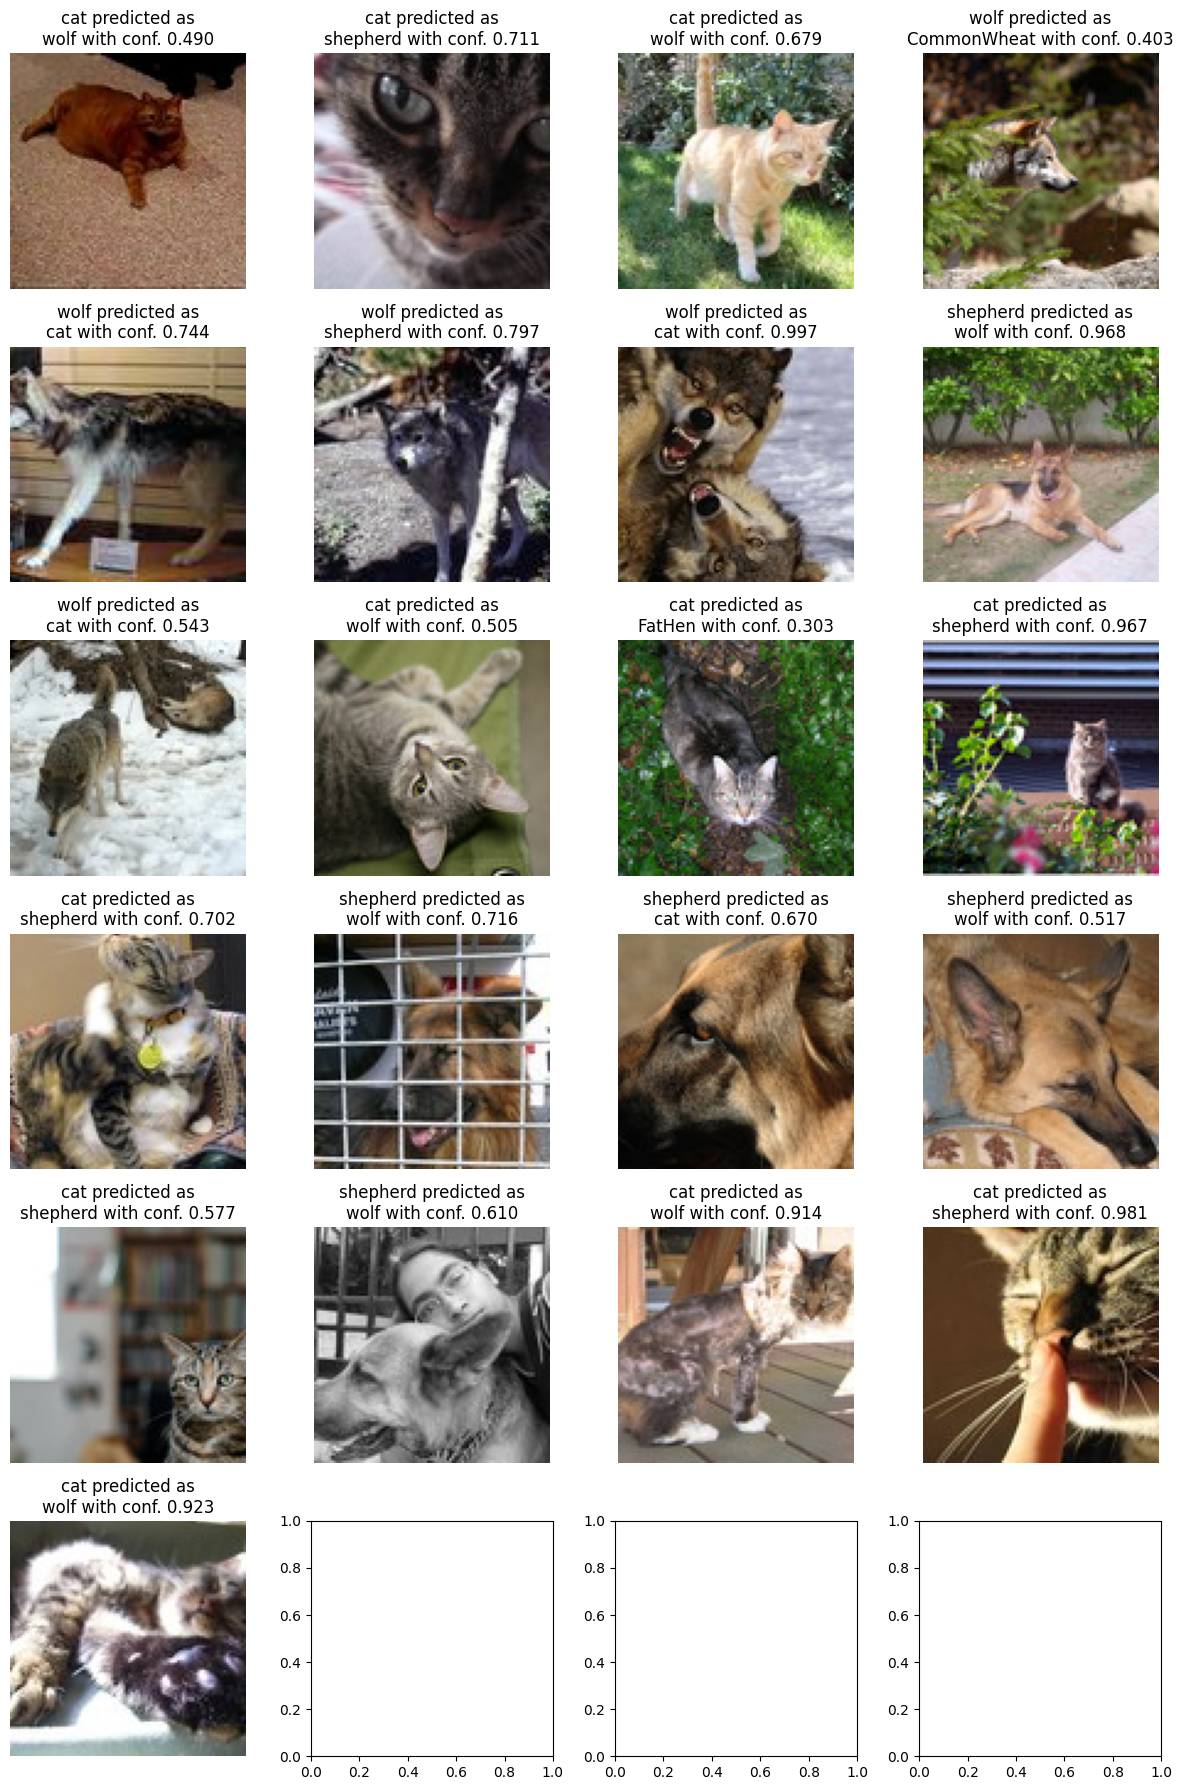

In [20]:
# Build a DataFrame for misclassified examples (here using the test_df from before)
test_df = test_df.copy()  # original test_df from split
# Append predictions and confidence (max logit probability converted to probability)
# Here we loop over the test dataset again to record predictions.
all_confidences = []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probabilities = torch.softmax(outputs, dim=1)
        all_confidences.extend(probabilities.max(dim=1)[0].cpu().numpy())

test_df['pred'] = all_preds
test_df['confidence'] = all_confidences

# Consider misclassifications involving animals (classes < num_animals)
false_animals_df = test_df[(test_df['class'] != test_df['pred']) &
                           ((test_df['class'] < num_animals) | (test_df['pred'] < num_animals))]
numfalse = false_animals_df.shape[0]
print("Number of misclassifications involving an animal:", numfalse)

# Display up to 50 misclassified images
num_show = min(numfalse, 50)
ncols = 4
nrows = math.ceil(num_show / ncols)
nrows = min(nrows, 15)
f, ax = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
for k in range(num_show):
    i = math.floor(k / ncols)
    j = k % ncols
    record = false_animals_df.iloc[k]
    path = record['path']
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax[i, j].imshow(img)
    ax[i, j].set_title(f"{classnames[record['class']]} predicted as\n{classnames[record['pred']]} with conf. {record['confidence']:.3f}", fontsize=12)
    ax[i, j].axis('off')
plt.tight_layout()
plt.show()